In [4]:
# Checking
# upload Dataset
from google.colab import files

uploaded = files.upload()

# Read Excel file
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [5]:
#Checking how many sheets it contains
excel_file = pd.ExcelFile("Telco_customer_churn.xlsx")

print(excel_file.sheet_names)

['Telco_Churn']


In [6]:
# only one sheet we will read it as
df = pd.read_excel(
    "Telco_customer_churn.xlsx",
    sheet_name="Telco_Churn"
)

# Customer Churn Prediction & Business Insights

## Import Required Libraries

In this section, we import all the libraries required for data manipulation, visualization, preprocessing, model building, and evaluation.

In [7]:
# ==============================
# Import Required Libraries


import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

## Load Dataset

The customer churn dataset is provided as an Excel (.xlsx) file. We load it into a Pandas DataFrame for further analysis.

In [8]:
# Upload and load dataset
from google.colab import files

uploaded = files.upload()

# Read Excel file
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")


Saving Telco_customer_churn.xlsx to Telco_customer_churn (1).xlsx


In [9]:
df = pd.read_excel(
    "Telco_customer_churn.xlsx",
    sheet_name="Telco_Churn"
)

## Preview Dataset

Let's inspect the first five rows to understand the structure and available features.

In [10]:
df.head()
df.tail()
df.sample(5, random_state=42)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
185,2189-WWOEW,1,United States,California,Keene,93531,"35.214982, -118.59049",35.214982,-118.590490,Female,...,Month-to-month,Yes,Bank transfer (automatic),85.9,1269.55,Yes,1,96,3579,Don't know
2715,2446-ZKVAF,1,United States,California,Stockton,95207,"38.002125, -121.324979",38.002125,-121.324979,Male,...,Month-to-month,No,Credit card (automatic),56.8,1074.65,No,0,59,5558,NaN
3825,4986-MXSFP,1,United States,California,San Leandro,94579,"37.687264, -122.15728",37.687264,-122.157280,Female,...,Month-to-month,Yes,Mailed check,20.0,40.9,No,0,39,2237,NaN
1807,5868-YWPDW,1,United States,California,Sherman Oaks,91423,"34.146957, -118.432138",34.146957,-118.432138,Male,...,Month-to-month,Yes,Electronic check,84.2,519.15,Yes,1,72,5834,Limited range of services
132,9412-GHEEC,1,United States,California,Murrieta,92563,"33.581045, -117.14719",33.581045,-117.147190,Male,...,Month-to-month,No,Bank transfer (automatic),104.8,4131.95,Yes,1,88,3492,Service dissatisfaction


## Dataset Shape

Understanding the number of observations and features helps estimate the dataset's size and complexity.


In [11]:
print("=" * 40)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print("=" * 40)

Rows    : 7043
Columns : 33


## Feature Names

Let's view all available columns in the dataset.

In [12]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [13]:
for col in df.columns:
    print(col)

CustomerID
Count
Country
State
City
Zip Code
Lat Long
Latitude
Longitude
Gender
Senior Citizen
Partner
Dependents
Tenure Months
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection
Tech Support
Streaming TV
Streaming Movies
Contract
Paperless Billing
Payment Method
Monthly Charges
Total Charges
Churn Label
Churn Value
Churn Score
CLTV
Churn Reason


## Dataset Information

Inspect the data types and identify missing values before preprocessing.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Statistical Summary

Generate descriptive statistics for both numerical and categorical features.

In [15]:
# Numerical
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [16]:
# Categorial
df.describe(include="object").T

,count,unique,top,freq
CustomerID,7043,7043,3186-AJIEK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


## Missing Value Analysis

Identify columns containing missing values.

In [17]:
missing = df.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

# Also display it's name

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_df[missing_df["Missing Values"] > 0].sort_values(
    by="Missing Values",
    ascending=False
)


,Missing Values,Percentage
Churn Reason,5174,73.463013


## Duplicate Record Analysis

Check whether duplicate observations exist in the dataset.

In [18]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


## Target Variable Distribution

Analyze the distribution of churned and retained customers.

In [19]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


In [20]:
# Percentage
df["Churn Label"].value_counts(normalize=True) * 100

,proportion
Churn Label,
No,73.463013
Yes,26.536987


# Data Cleaning

Before building machine learning models, we clean the dataset by:

- Removing irrelevant columns
- Removing data leakage columns
- Converting data types
- Preparing features for modeling

In [21]:
# Make A copy
df_copy = df.copy()

In [22]:
df_clean = df.copy()

In [23]:
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")

In [24]:
# Drop columns
drop_columns = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude"
]

df_clean.drop(columns=drop_columns, inplace=True)

In [25]:
# drop data leakage
leakage_columns = [
    "Churn Label",
    "Churn Score",
    "Churn Reason"
]

df_clean.drop(columns=leakage_columns, inplace=True)

In [26]:
#Check the result
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [27]:
# convert total charges
df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)

Section 3: Exploratory Data Analysis (EDA)
# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the relationships between customer characteristics and churn. It enables us to identify patterns, trends, and factors influencing customer retention before building predictive models.

In [28]:
#import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

## Customer Churn Distribution

Analyze the proportion of customers who stayed versus those who churned.

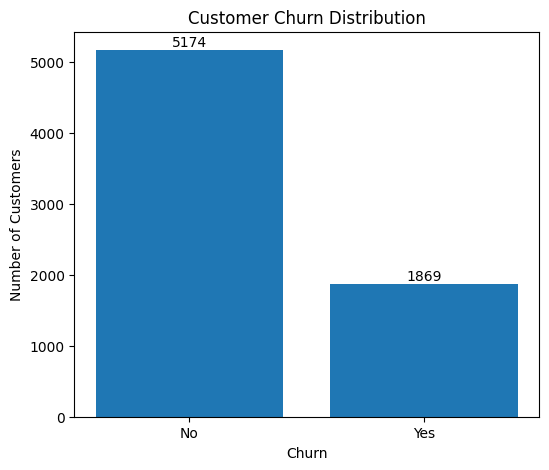

In [29]:
churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    churn_counts.index,
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for i, value in enumerate(churn_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.show()

### Business Insight
### Observation

- Most customers did not churn.
- Approximately **26.5%** of customers left the company.
- The dataset is moderately imbalanced, which should be considered during model evaluation.

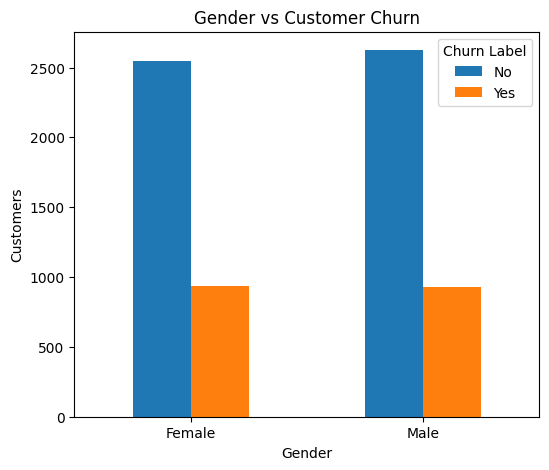

In [30]:
# Gender vs Churn
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn Label"]
)

gender_churn.plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Gender vs Customer Churn")
plt.xlabel("Gender")
plt.ylabel("Customers")
plt.xticks(rotation=0)
plt.show()

### Observation

Male and female customers exhibit similar churn behavior, suggesting that gender alone is not a strong predictor of customer churn.

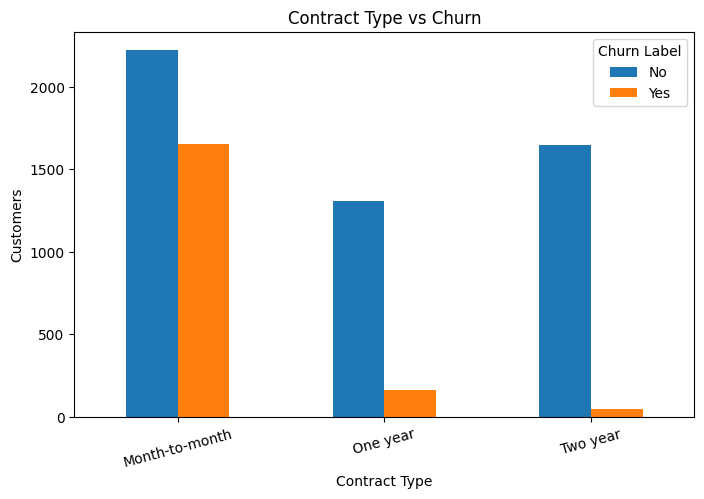

In [31]:
# Contract type vs churn
contract = pd.crosstab(
    df["Contract"],
    df["Churn Label"]
)

contract.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Customers")
plt.xticks(rotation=15)
plt.show()

### Observation

Customers with **month-to-month contracts** exhibit substantially higher churn than customers with one-year or two-year contracts, indicating contract duration is a strong retention factor.

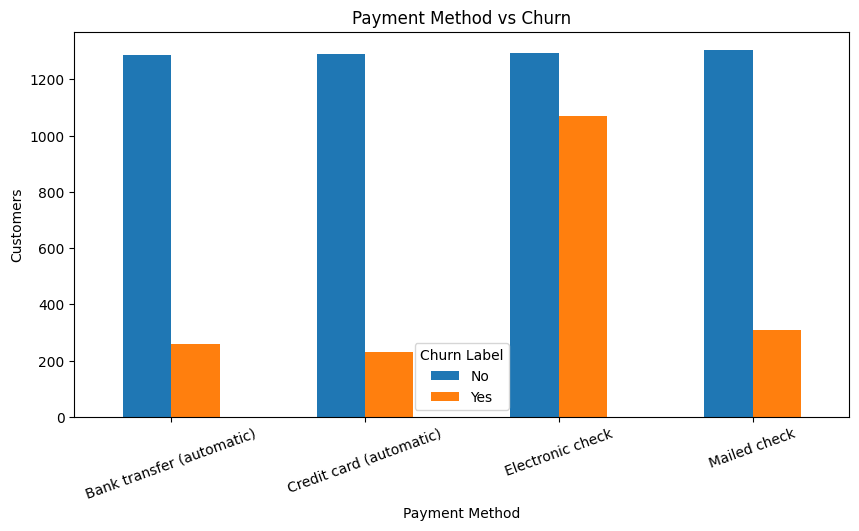

In [32]:
# Payment Method vs Churn
payment = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"]
)

payment.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Payment Method vs Churn")
plt.xlabel("Payment Method")
plt.ylabel("Customers")
plt.xticks(rotation=20)

plt.show()

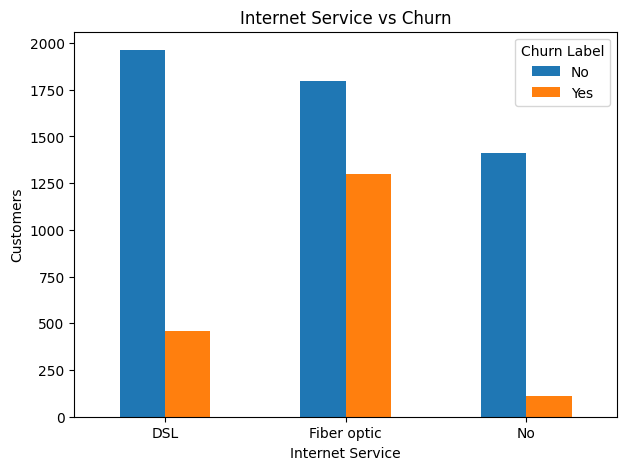

In [33]:
# Internet Servive Vs Churn ]
internet = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"]
)

internet.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Customers")

plt.xticks(rotation=0)

plt.show()

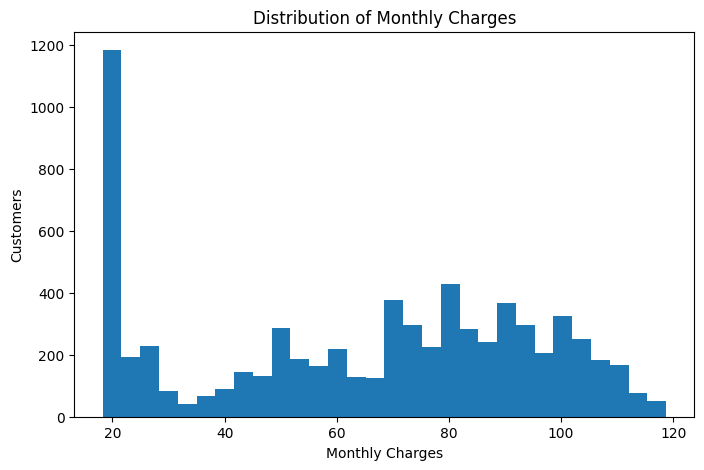

In [34]:
# Mpnthly Charges Vs churn
plt.figure(figsize=(8,5))

plt.hist(
    df["Monthly Charges"],
    bins=30
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Customers")

plt.show()

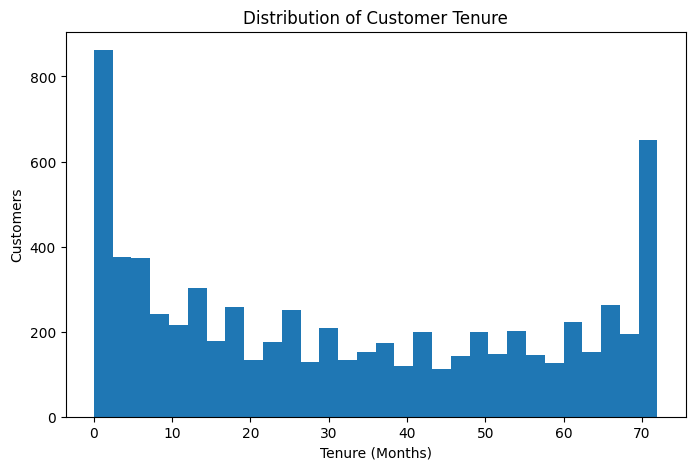

In [35]:
# Tenure Distribution ]
plt.figure(figsize=(8,5))

plt.hist(
    df["Tenure Months"],
    bins=30
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Customers")

plt.show()

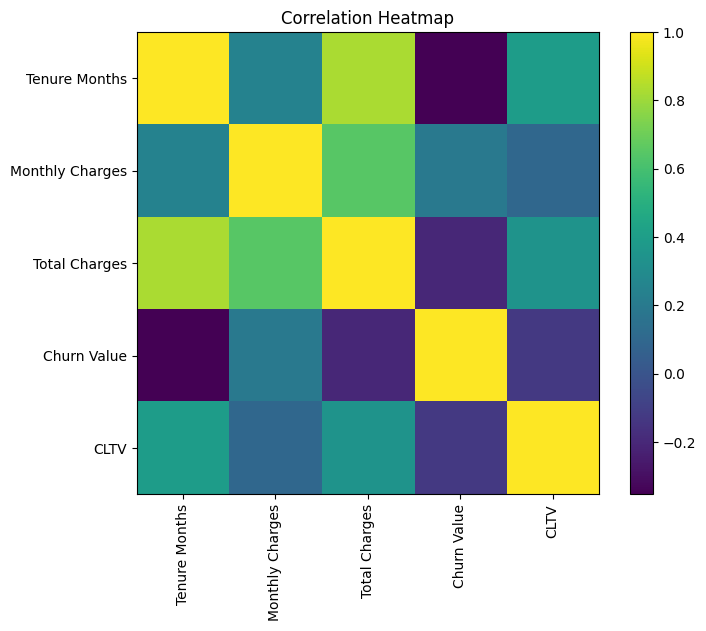

In [36]:
# Correalation Heatmap
corr = df_clean.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.show()

Section 4: Data Preprocessing & Feature Engineering
# Data Preprocessing

Before training machine learning models, categorical variables must be converted into numerical values. This section prepares the dataset by encoding categorical features, separating the target variable, and splitting the data into training and testing sets.

In [78]:
# Features and Targets
X = df_clean.drop(columns=["Churn Value"])
y = df_clean["Churn Value"]

In [79]:
# Checking Remaining Columns
df_clean.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'CLTV'],
      dtype='object')

In [80]:
# seperate Features and Tragets
X = df_clean.drop("Churn Value", axis=1)

y = df_clean["Churn Value"]

print(X.shape)
print(y.shape)

(7043, 20)
(7043,)


In [81]:
# Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

X = X.copy()

encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [82]:
X.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,3239
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,2701
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,5372
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,5003
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,5340


In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [84]:
# Verify shapes
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (5634, 20)
Testing Features  : (1409, 20)
Training Labels   : (5634,)
Testing Labels    : (1409,)


In [85]:
# Filling Null Values

df_clean["Total Charges"] = pd.to_numeric(
    df_clean["Total Charges"],
    errors="coerce"
)


In [86]:
X.isnull().sum().sort_values(ascending=False)

,0
Gender,0
Senior Citizen,0
Partner,0
Dependents,0
Tenure Months,0
Phone Service,0
Multiple Lines,0
Internet Service,0
Online Security,0
Online Backup,0


In [87]:
df_clean["Total Charges"] = df_clean["Total Charges"].fillna(
    df_clean["Total Charges"].median()
)

In [88]:
# Train-Test and split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [89]:
# verify
print(X_train.shape)
print(X_test.shape)

print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

(5634, 20)
(1409, 20)
0
0


Section 5: Build Machine Learning Models

We'll compare four models:

Logistic Regression
Decision Tree
Random Forest ⭐
Gradient Boosting

In [90]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [59]:
# Create a reuseable function '
def evaluate_model(model, X_test, y_test):
    ...

In [91]:
# Evaluate
print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.65      0.59      0.62       374

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [92]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [93]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [94]:
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [95]:
# Fianl Comparison Table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

results.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.805536,0.647059,0.588235,0.616246
1,Gradient Boosting,0.800568,0.653465,0.529412,0.584934
2,Random Forest,0.792761,0.636667,0.510695,0.566766
3,Decision Tree,0.728886,0.489362,0.491979,0.490667


In [96]:
#Classification Report

# Logistic Regression
print("Decision Tree")
print(classification_report(y_test, dt_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [97]:
# Decision Tree
print("Decision Tree")
print(classification_report(y_test, dt_pred))

Decision Tree
              precision    recall  f1-score   support

           0       0.82      0.81      0.82      1035
           1       0.49      0.49      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [98]:
# Random forest
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [99]:
# gradient Boosting
print("Gradient Boosting")
print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



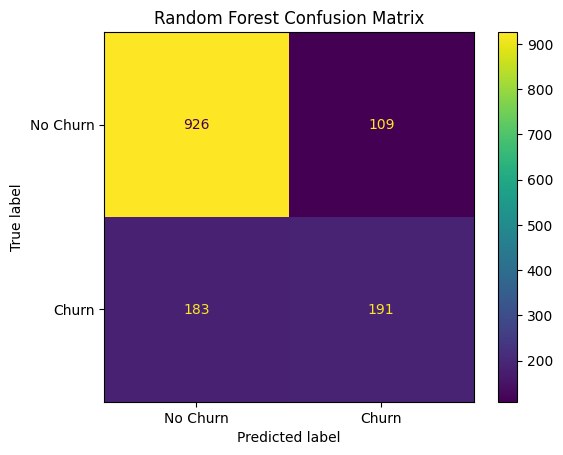

In [100]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["No Churn", "Churn"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

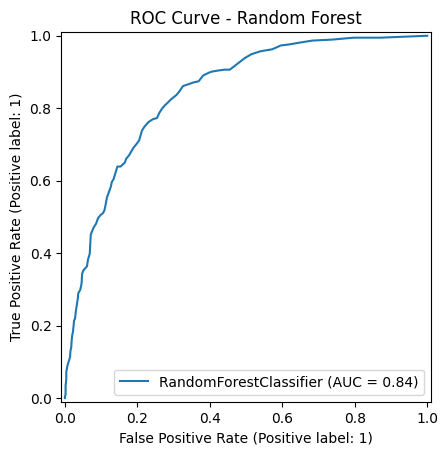

In [101]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

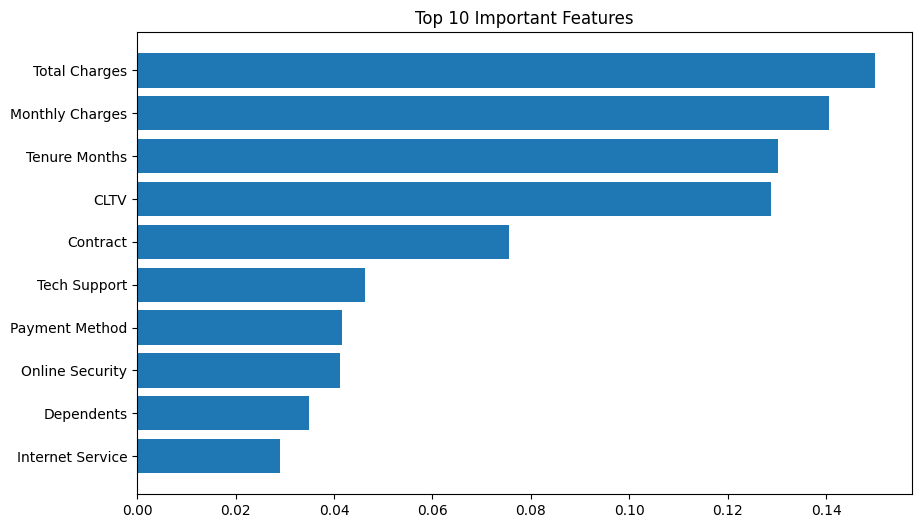

In [102]:
# Features Importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

# Key Business Insights

### Key Findings

- Customers with month-to-month contracts exhibit significantly higher churn rates.
- Longer customer tenure is associated with lower churn.
- Customers paying higher monthly charges are more likely to leave.
- The absence of online security and technical support services is linked to increased churn.
- Contract type, tenure, and monthly charges are the strongest predictors of customer retention.

### Business Recommendations

- Encourage customers to switch from month-to-month to annual contracts.
- Offer retention incentives to new customers during their first year.
- Bundle technical support and online security services.
- Identify high-risk customers early and target them with personalized retention offers.

Phase 6: Hyperparameter Tuning
# Hyperparameter Tuning

To improve predictive performance, GridSearchCV is used to identify the optimal combination of hyperparameters through cross-validation.

In [103]:
#Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [104]:
# Define Parameter Grid
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

In [105]:
# Perform Grid Search
grid_lr = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='f1')

In [106]:
# Best Parameter
print("Best Parameters:")
print(grid_lr.best_params_)

print("\nBest Cross Validation F1:")
print(grid_lr.best_score_)

Best Parameters:
{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}

Best Cross Validation F1:
0.6252852813140276


In [112]:
# best model
best_lr = grid_lr.best_estimator_

In [111]:
# Prediction
best_pred = best_lr.predict(X_test)

In [109]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall   :", recall_score(y_test, best_pred))
print("F1 Score :", f1_score(y_test, best_pred))

Accuracy : 0.8055358410220014
Precision: 0.6470588235294118
Recall   : 0.5882352941176471
F1 Score : 0.6162464985994398


In [110]:
# classification Report
print(classification_report(y_test, best_pred))

              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1035
           1       0.65      0.59      0.62       374

    accuracy                           0.81      1409
   macro avg       0.75      0.74      0.74      1409
weighted avg       0.80      0.81      0.80      1409



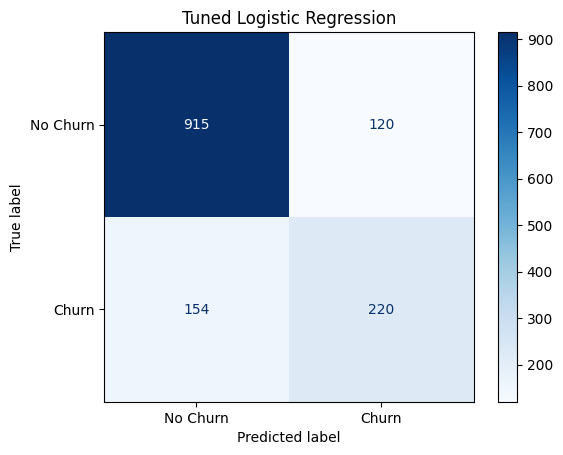

In [113]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Tuned Logistic Regression")

plt.show()

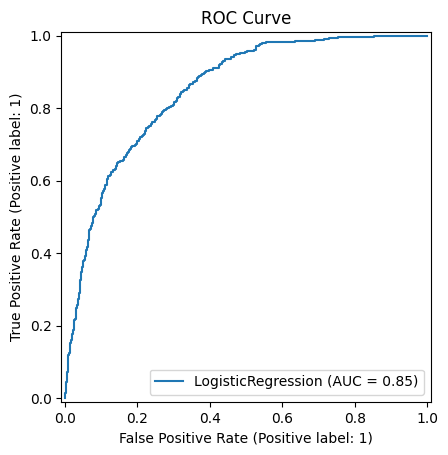

In [114]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

plt.title("ROC Curve")

plt.show()

In [115]:
# ROC-AUC Score
from sklearn.metrics import roc_auc_score

y_prob = best_lr.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.8495


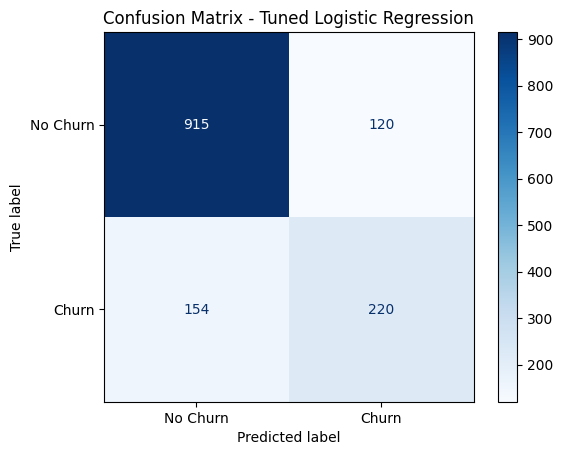

In [116]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_lr,
    X_test,
    y_test,
    display_labels=["No Churn", "Churn"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

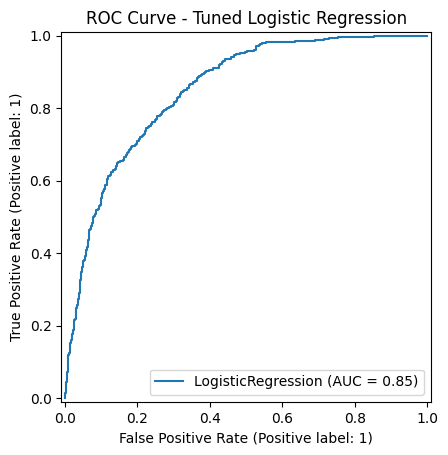

In [117]:
# ROC Curve
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    best_lr,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned Logistic Regression")
plt.show()

In [118]:
# Features Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_lr.coef_[0]
})

importance["Absolute Coefficient"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

importance.head(10)

,Feature,Coefficient,Absolute Coefficient
3,Dependents,-1.630992,1.630992
5,Phone Service,-0.817816,0.817816
14,Contract,-0.771805,0.771805
15,Paperless Billing,0.361747,0.361747
2,Partner,0.315317,0.315317
8,Online Security,-0.287598,0.287598
11,Tech Support,-0.270020,0.270020
7,Internet Service,0.152739,0.152739
9,Online Backup,-0.133940,0.133940
6,Multiple Lines,0.113078,0.113078


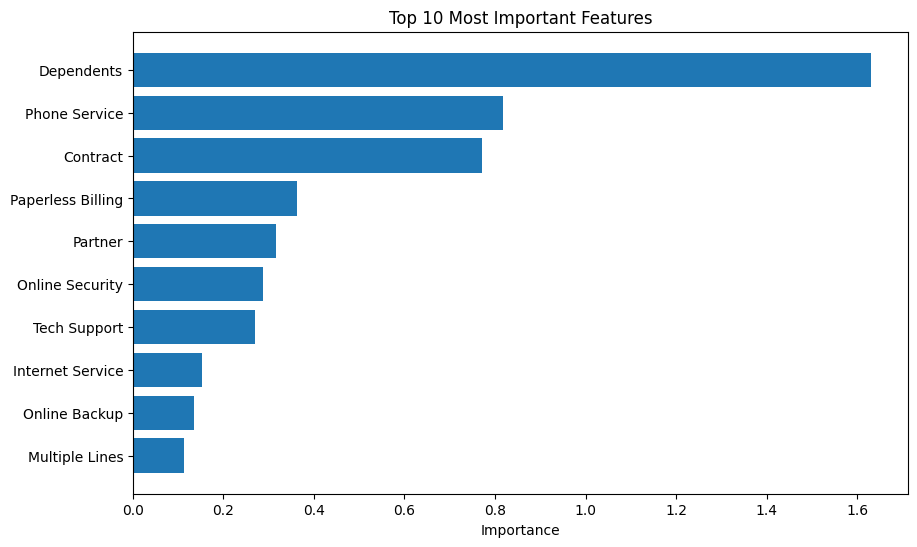

In [119]:
# Plot Top Features
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Feature"],
    top10["Absolute Coefficient"]
)

plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

In [120]:
# Save Model
import pickle

pickle.dump(best_lr, open("best_logistic_regression.pkl", "wb"))

In [121]:
# Save Encoders
pickle.dump(encoders, open("label_encoders.pkl", "wb"))

In [122]:
# Verify
import os

os.listdir()

['.config',
 'Telco_customer_churn.xlsx',
 'best_logistic_regression.pkl',
 'label_encoders.pkl',
 'Telco_customer_churn (1).xlsx',
 'sample_data']

In [124]:
# Download
from google.colab import files

files.download("best_logistic_regression.pkl")
files.download("label_encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>